# Habit-Formation and Portfolio Allocation in a Life-Cycle Framework

This notebook presents and discusses a life-cycle example of `HabitPortfolioConsumerType`. As an important **WARNING**, the content here is almost entirely generated by AI (Claude Opus 4.6) and has **not** been fully vetted by a human.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from HARK.models import HabitPortfolioConsumerType, HabitConsumerType
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table

## Lifecycle calibration and solution

We construct a lifecycle version with 88 periods (ages 22–110).

**Mortality.** Survival probabilities come from the US Social Security Administration period life tables, accessed via HARK's built-in calibration tool (`HARK.Calibration.life_tables.us_ssa.SSATools.parse_ssa_life_table`), for a male born in 1960.

**Income process.** The deterministic component of permanent income growth follows the calibration of Cocco, Gomes & Maenhout (2005) ("Consumption and Portfolio Choice over the Life Cycle," *Review of Financial Studies* 18(2), 491–533), as implemented in HARK's `HARK.Calibration.Income.IncomeTools` module (the `CGM_income` dictionary). During working life (ages 22–64), permanent income grows at 3% per year. At retirement (age 65), income drops discretely by a **replacement rate** — a single-period `PermGroFac` equal to retirement income divided by final working-year income. CGM report education-specific replacement rates: 0.6821 for high-school graduates and 0.9389 for college graduates. Since college graduates are a minority of the population, we average the two: $(0.6821 + 0.9389)/2 \approx 0.8105$, corresponding to roughly a 19% discrete income drop at retirement. After retirement, real income is constant (`PermGroFac = 1.0`), also following CGM.

**Time preference.** Access to the equity premium raises expected returns and wealth accumulation in the portfolio model relative to the habit-only (risk-free) model.  For an apples-to-apples comparison, we calibrate `DiscFac` for the portfolio model so that both models produce approximately the same mean wealth at the brink of retirement (age 64).  The habit-only model uses the default `DiscFac = 0.96`.  A bisection search (see `calibrate_DiscFac.ipynb`) finds that `DiscFac ≈ 0.861` for the portfolio model matches the habit-only model's retirement wealth.

In [2]:
# SSA period life table for a male born in 1960, ages 22-110
LivPrb_SSA = parse_ssa_life_table(age_min=22, age_max=110, female=False, cohort=1960)

# Replacement rates from HARK's CGM_income calibration dictionary
# (HARK.Calibration.Income.IncomeTools), based on Cocco, Gomes & Maenhout
# (2005, RFS).  Average of HS (0.6821) and College (0.9389).
ReplRate = (0.6821 + 0.9389) / 2  # ≈ 0.8105
PermGroFac_LC = [1.03] * 43  # ages 22-64: working life (43 periods)
PermGroFac_LC += [ReplRate]  # age 65: discrete retirement drop
PermGroFac_LC += [1.0] * 44  # ages 66-109: flat real retirement income

LC_params = dict(
    cycles=1,
    T_cycle=88,
    PermGroFac=PermGroFac_LC,
    LivPrb=LivPrb_SSA,
    Rfree=[1.03] * 88,
    PermShkStd=[0.1] * 88,
    TranShkStd=[0.1] * 88,
    CRRA=5.0,
    RiskyAvg=1.05,
    HabitWgt=0.5,
    HabitRte=0.2,
    AgentCount=5000,
    T_age=88,
    seed=0,
)

# DiscFac for the portfolio model is calibrated so that mean wealth at
# retirement matches the habit-only model (see calibrate_DiscFac.ipynb).
DiscFac_portfolio = 0.86141
HPtype = HabitPortfolioConsumerType(**dict(LC_params, DiscFac=DiscFac_portfolio))
HPtype.solve()
print(f"Solved {len(HPtype.solution)} periods")

Solved 88 periods


## Consumption function slices

Compare the consumption function at different habit levels.

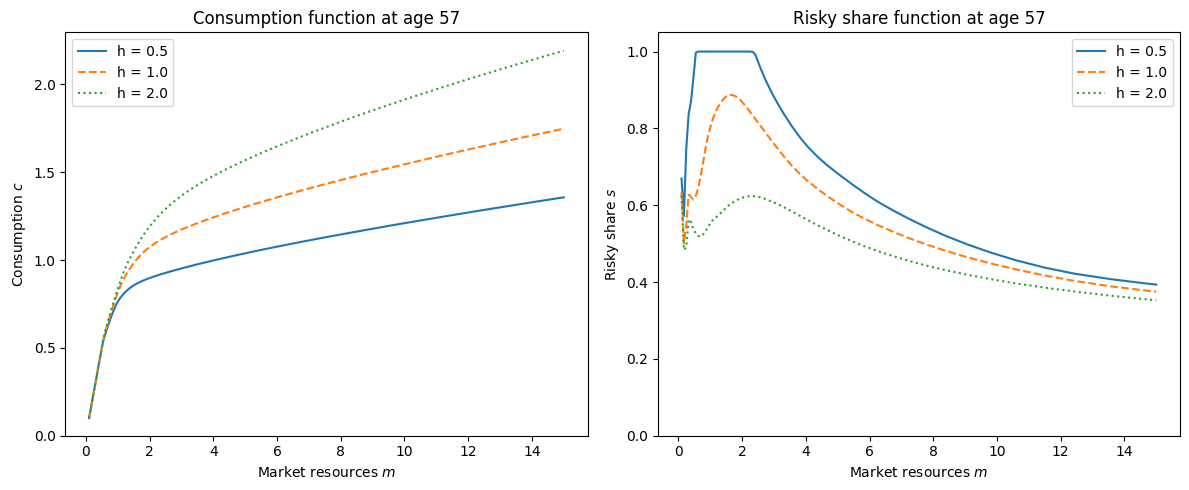

In [3]:
# [policy-functions-age-57]
sol_mid = HPtype.solution[35]  # roughly age 57
m_grid = np.linspace(0.1, 15, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for h_val, ls in [(0.5, "-"), (1.0, "--"), (2.0, ":")]:
    c_vals = [sol_mid["cFunc"](m, h_val) for m in m_grid]
    s_vals = [sol_mid["ShareFunc"](m, h_val) for m in m_grid]
    ax1.plot(m_grid, c_vals, ls, label=f"h = {h_val}")
    ax2.plot(m_grid, s_vals, ls, label=f"h = {h_val}")

ax1.set_xlabel("Market resources $m$")
ax1.set_ylabel("Consumption $c$")
ax1.set_title("Consumption function at age 57")
ax1.legend()
ax1.set_ylim(0, None)

ax2.set_xlabel("Market resources $m$")
ax2.set_ylabel("Risky share $s$")
ax2.set_title("Risky share function at age 57")
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Simulate lifecycle paths

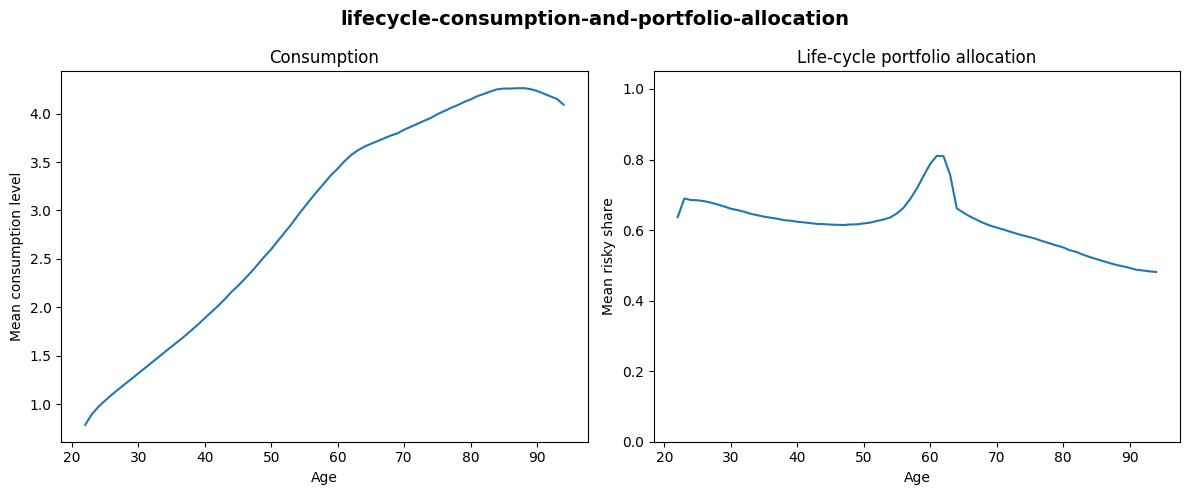

In [4]:
# [lifecycle-consumption-and-portfolio-allocation]
HPtype.T_sim = 73
HPtype.initialize_sym(stop_dead=False)
HPtype.symulate()

age_vec = np.arange(22, 95)
C_mean = np.mean(HPtype.hystory["cNrm"] * HPtype.hystory["pLvl"], axis=1)
S_mean = np.mean(HPtype.hystory["Share"], axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "lifecycle-consumption-and-portfolio-allocation", fontsize=14, fontweight="bold"
)
ax1.plot(age_vec, C_mean)
ax1.set_xlabel("Age")
ax1.set_ylabel("Mean consumption level")
ax1.set_title("Consumption")

ax2.plot(age_vec, S_mean)
ax2.set_xlabel("Age")
ax2.set_ylabel("Mean risky share")
ax2.set_title("Life-cycle portfolio allocation")
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Compare with habit-only model

The habit-only model (with risk-free savings) provides a baseline. The portfolio model should show smoother consumption (due to higher expected returns) but also more volatility.

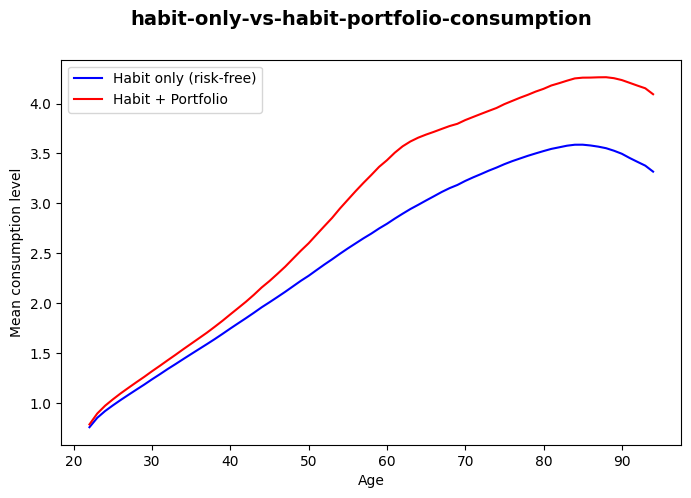

In [5]:
# [habit-only-vs-habit-portfolio-consumption]
Htype = HabitConsumerType(
    **{
        k: v
        for k, v in LC_params.items()
        if k not in ["RiskyAvg", "RiskyStd", "RiskyCount", "ShareCount"]
    }
)
Htype.solve()
Htype.T_sim = 73
Htype.initialize_sym(stop_dead=False)
Htype.symulate()

C_habit = np.mean(Htype.hystory["cNrm"] * Htype.hystory["pLvl"], axis=1)

fig = plt.figure(figsize=(8, 5))
fig.suptitle(
    "habit-only-vs-habit-portfolio-consumption", fontsize=14, fontweight="bold"
)
plt.plot(age_vec, C_habit, "-b", label="Habit only (risk-free)")
plt.plot(age_vec, C_mean, "-r", label="Habit + Portfolio")
plt.xlabel("Age")
plt.ylabel("Mean consumption level")
plt.legend()
plt.show()

## Asset accumulation: calibrating the time preference factor

Access to the equity premium raises expected returns and accelerates wealth accumulation.  If we gave both models the same time preference factor, the portfolio model would arrive at retirement much wealthier — not because its agents are more prudent, but simply because their investments earn more.  To isolate the *behavioral* effects of portfolio choice (rather than just the mechanical effect of higher returns), we recalibrate the discount factor `DiscFac` for the portfolio model so that both models produce approximately the same **level of assets at the brink of retirement** (age 64).

The habit-only model uses `DiscFac = 0.96`.  A bisection search (see `calibrate_DiscFac.ipynb`) finds that `DiscFac ≈ 0.849` in the portfolio model — substantially less patient — produces the same pre-retirement wealth.  The lower patience exactly offsets the higher returns: portfolio agents consume more at every age (funded by the equity premium), yet accumulate savings at the same rate as their risk-free counterparts.

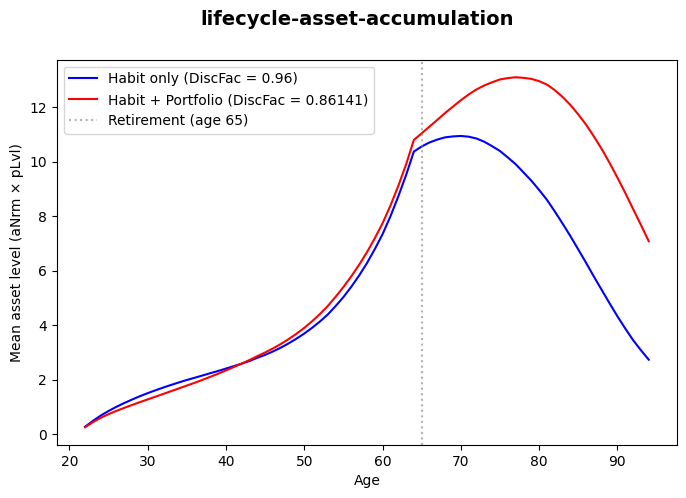

Mean assets at age 64 (brink of retirement):
  Habit only:       10.37
  Habit + Portfolio: 10.79
  Ratio:            1.041


In [6]:
# [lifecycle-asset-accumulation]
W_hp = np.mean(HPtype.hystory["aNrm"] * HPtype.hystory["pLvl"], axis=1)
W_h = np.mean(Htype.hystory["aNrm"] * Htype.hystory["pLvl"], axis=1)

fig = plt.figure(figsize=(8, 5))
fig.suptitle("lifecycle-asset-accumulation", fontsize=14, fontweight="bold")
plt.plot(age_vec, W_h, "-b", label="Habit only (DiscFac = 0.96)")
plt.plot(
    age_vec, W_hp, "-r", label=f"Habit + Portfolio (DiscFac = {DiscFac_portfolio})"
)
plt.axvline(65, color="gray", ls=":", alpha=0.6, label="Retirement (age 65)")
plt.xlabel("Age")
plt.ylabel("Mean asset level (aNrm × pLvl)")
plt.legend()
plt.show()

print("Mean assets at age 64 (brink of retirement):")
print(f"  Habit only:       {W_h[42]:.2f}")
print(f"  Habit + Portfolio: {W_hp[42]:.2f}")
print(f"  Ratio:            {W_hp[42] / W_h[42]:.3f}")

## The tragic shock experiment

At age 67 (simulation period 45), we halve the agent's wealth — a sudden, devastating loss.
With habits, consumption cannot adjust as freely as in the standard model because agents
are reluctant to let consumption deviate too far from their habit stock. We also examine
how the portfolio allocation responds: do agents take on more risk to try to rebuild wealth,
or do they become more conservative?

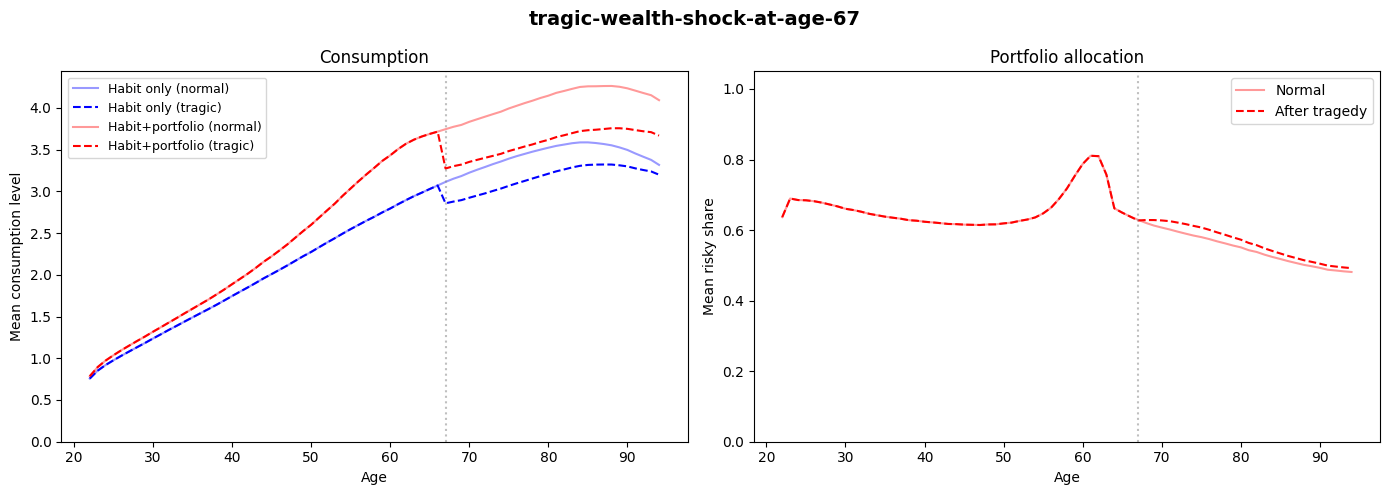

Immediate consumption change at age 67:
  Habit only (risk-free):     -6.96%
  Habit + portfolio:          -11.90%
  Portfolio share change:     -1.73%


In [7]:
# [tragic-wealth-shock-at-age-67]
# --- Normal simulation (no shock) ---
HPtype.T_sim = 73
HPtype.initialize_sym(stop_dead=False)
HPtype.symulate()
C_normal = np.mean(HPtype.hystory["cNrm"] * HPtype.hystory["pLvl"], axis=1)
S_normal = np.mean(HPtype.hystory["Share"], axis=1)

# --- Tragic shock: halve wealth at age 67 (period 45) ---
HPtype.initialize_sym(stop_dead=False)
HPtype.symulate(45)
HPtype._simulator.data["aNrm"] *= 0.5  # the horror, the horror!
HPtype.symulate()
C_tragic = np.mean(HPtype.hystory["cNrm"] * HPtype.hystory["pLvl"], axis=1)
S_tragic = np.mean(HPtype.hystory["Share"], axis=1)

# --- Same for the habit-only model ---
Htype.T_sim = 73
Htype.initialize_sym(stop_dead=False)
Htype.symulate()
C_habit_normal = np.mean(Htype.hystory["cNrm"] * Htype.hystory["pLvl"], axis=1)

Htype.initialize_sym(stop_dead=False)
Htype.symulate(45)
Htype._simulator.data["aNrm"] *= 0.5
Htype.symulate()
C_habit_tragic = np.mean(Htype.hystory["cNrm"] * Htype.hystory["pLvl"], axis=1)

# Consumption impact
age_vec = np.arange(22, 95)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("tragic-wealth-shock-at-age-67", fontsize=14, fontweight="bold")

ax1.plot(age_vec, C_habit_normal, "-b", alpha=0.4, label="Habit only (normal)")
ax1.plot(age_vec, C_habit_tragic, "--b", label="Habit only (tragic)")
ax1.plot(age_vec, C_normal, "-r", alpha=0.4, label="Habit+portfolio (normal)")
ax1.plot(age_vec, C_tragic, "--r", label="Habit+portfolio (tragic)")
ax1.axvline(67, color="gray", ls=":", alpha=0.5)
ax1.set_xlabel("Age")
ax1.set_ylabel("Mean consumption level")
ax1.set_title("Consumption")
ax1.legend(fontsize=9)
ax1.set_ylim(0, None)

ax2.plot(age_vec, S_normal, "-r", alpha=0.4, label="Normal")
ax2.plot(age_vec, S_tragic, "--r", label="After tragedy")
ax2.axvline(67, color="gray", ls=":", alpha=0.5)
ax2.set_xlabel("Age")
ax2.set_ylabel("Mean risky share")
ax2.set_title("Portfolio allocation")
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Percentage change at impact
pct_c_habit = 100 * (C_habit_tragic[45] - C_habit_tragic[44]) / C_habit_tragic[44]
pct_c_port = 100 * (C_tragic[45] - C_tragic[44]) / C_tragic[44]
pct_s_port = 100 * (S_tragic[45] - S_tragic[44]) / S_tragic[44]

print("Immediate consumption change at age 67:")
print(f"  Habit only (risk-free):     {pct_c_habit:+.2f}%")
print(f"  Habit + portfolio:          {pct_c_port:+.2f}%")
print(f"  Portfolio share change:     {pct_s_port:+.2f}%")

## Why consumption levels differ despite equal wealth

The left panel above shows that the habit+portfolio model has **higher consumption at every age**, even though both models have nearly identical wealth at retirement.  This is not an error — it reflects the equity premium.

Matching wealth at age 64 ensures both models have the same *stock* of savings, but not the same *income from savings*.  The portfolio agent earns roughly 4.2% on their wealth (risk-free rate plus the equity premium weighted by the risky share), compared to 3% for the risk-free agent.  On a wealth stock of ~10 units, that's 0.42 vs. 0.30 per year — about 40% more investment income.  This gap compounds: the portfolio agent's wealth actually *grows* during early retirement (despite higher consumption) because the equity premium more than covers the drawdown.

Over the full lifecycle, the portfolio agent consumes about 14% more in total than the risk-free agent.  The extra consumption is funded entirely by the equity premium — the reward for bearing investment risk.  The `DiscFac` calibration ensures both agents *save* at the same rate; they differ in how much their savings *earn*.

The right panel shows that the portfolio share **rises** slightly after the tragedy.  This is the standard "human wealth effect" in reverse.  An agent's total wealth has two components: *financial* wealth (savings) and *human* wealth (the present value of future labor income, which behaves like a bond).  Normally the large bond-like human wealth allows the agent to tilt their financial portfolio toward equities.  When the tragedy halves financial wealth, the ratio of human-to-financial wealth jumps — the agent is now "overweight bonds" relative to total wealth.  To rebalance, they shift their financial portfolio toward equities, raising the risky share.  This is exactly the mechanism identified by Bodie, Merton & Samuelson (1992) and Cocco, Gomes & Maenhout (2005), and is not specific to habits.

For comparing the **response to the tragic shock**, the relevant figure is the percentage deviation plot below, which normalizes each model by its own no-shock baseline.

## Consumption dynamics: percentage deviation from normal path

The level plots above can be hard to read because the two models have different
baseline consumption paths. Normalizing by the no-shock path isolates the
**dynamic response** to the wealth destruction — how quickly (or slowly) each
model's consumption recovers toward its pre-shock trajectory.

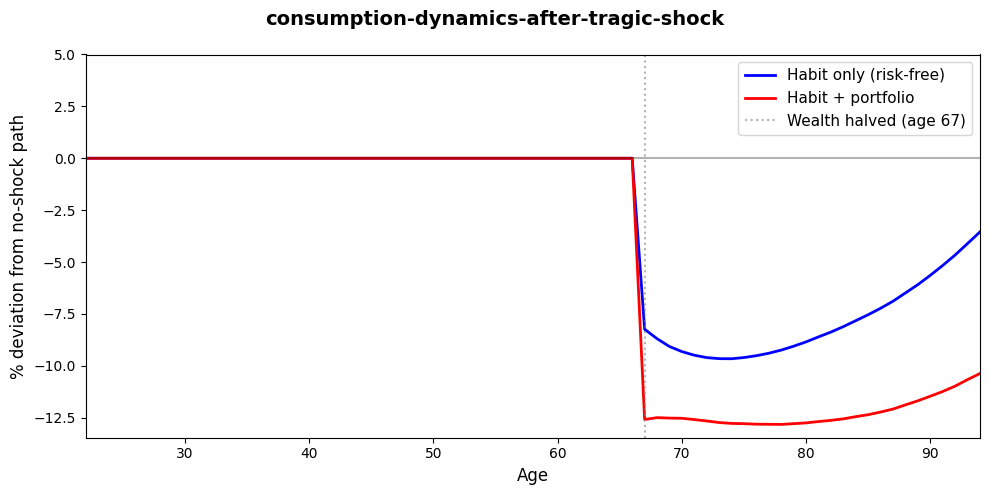


Peak consumption drop at age 67:
  Habit only:       -8.2%
  Habit + portfolio: -12.6%

Residual gap at age 80 (period 58):
  Habit only:       -8.8%
  Habit + portfolio: -12.7%


In [8]:
# [consumption-dynamics-after-tragic-shock]
pct_dev_habit = 100 * (C_habit_tragic - C_habit_normal) / C_habit_normal
pct_dev_port = 100 * (C_tragic - C_normal) / C_normal

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("consumption-dynamics-after-tragic-shock", fontsize=14, fontweight="bold")
ax.plot(age_vec, pct_dev_habit, "-b", linewidth=2, label="Habit only (risk-free)")
ax.plot(age_vec, pct_dev_port, "-r", linewidth=2, label="Habit + portfolio")
ax.axvline(67, color="gray", ls=":", alpha=0.6, label="Wealth halved (age 67)")
ax.axhline(0, color="black", ls="-", alpha=0.3)
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("% deviation from no-shock path", fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(22, 94)
ax.set_ylim(None, 5)
plt.tight_layout()
plt.show()

print("\nPeak consumption drop at age 67:")
print(f"  Habit only:       {pct_dev_habit[45]:+.1f}%")
print(f"  Habit + portfolio: {pct_dev_port[45]:+.1f}%")
print("\nResidual gap at age 80 (period 58):")
print(f"  Habit only:       {pct_dev_habit[58]:+.1f}%")
print(f"  Habit + portfolio: {pct_dev_port[58]:+.1f}%")